# GBDT vs NN

Thin orchestration notebook for the default `NN` vs `GBDT` analysis.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

notebook_dir = Path.cwd()
project_dir = notebook_dir.parent
repo_root = project_dir.parent

sys.path.insert(0, str(project_dir / "src"))
sys.path.insert(0, str(repo_root / "tabarena" / "tabarena"))

In [2]:
from mfa import load_config, run_analysis

config = load_config(project_dir / "configs" / "config_0.yaml")
result = run_analysis(
    config,
    # datasets=[
    #     # "qsar-biodeg", "APSFailure", "Amazon_employee_access",
    #     "Fitness_Club"
    # ],
)
result.analysis_table.head()

20:49:56 INFO mfa.pipeline: Starting analysis: comparisons=nn_vs_tree; scope=38 selected dataset(s); unit=dataset; method_variant=tuned; n_jobs=32
20:49:56 INFO mfa.pipeline: Stage 1/5 raw results: cache hit (11286 rows, 38 dataset(s))
20:49:56 WARNING mfa.groups: Group `tfm` contains config_types absent from data: TABICLV2, TABICL_GPU, TABPFN-V2.6
20:49:56 INFO mfa.pipeline: Stage 2/5 meta-features: cache hit (594 rows, 38 dataset(s))
20:49:56 INFO mfa.pipeline: Stage 3/5 pairwise gaps: cache hit (594 rows, 38 dataset(s))
20:49:56 INFO mfa.pipeline: Stage 4/5 analysis table: joining and aggregating at dataset level
20:49:56 INFO mfa.pipeline: Stage 4/5 analysis table: ready (38 rows, 38 dataset(s))
20:49:56 INFO mfa.pipeline: Stage 5/5 statistics: cache hit (6 correlation test(s), 0 rejected after bh)
20:49:56 INFO mfa.pipeline: Analysis complete: config_hash=07b73072198c788d


,dataset,comparison_name,group_a_name,group_b_name,group_a_label,group_b_label,expected_direction,n_splits,n,d,...,best_a_error,best_a_norm_error,best_b_error,best_b_norm_error,delta_raw,delta_raw_std,delta_raw_sem,delta_norm,delta_norm_std,delta_norm_sem
0,APSFailure,nn_vs_tree,nn,tree,mlp-based,tree-based,NaN,9,50666.666667,170.0,...,0.008445,0.675884,0.007947,0.434947,0.000498,0.001099,0.000366,0.240937,0.421656,0.140552
1,Amazon_employee_access,nn_vs_tree,nn,tree,mlp-based,tree-based,NaN,9,21846.000000,9.0,...,0.129804,0.351413,0.116781,0.000000,0.013023,0.004252,0.001417,0.351413,0.084342,0.028114
2,Bank_Customer_Churn,nn_vs_tree,nn,tree,mlp-based,tree-based,NaN,9,6666.666667,10.0,...,0.130036,0.540574,0.129614,0.488169,0.000422,0.001437,0.000479,0.052405,0.183040,0.061013
3,Bioresponse,nn_vs_tree,nn,tree,mlp-based,tree-based,NaN,9,2500.666667,1776.0,...,0.129431,0.772322,0.124434,0.350865,0.004997,0.004129,0.001376,0.421457,0.370556,0.123519
4,Diabetes130US,nn_vs_tree,nn,tree,mlp-based,tree-based,NaN,9,47678.666667,47.0,...,0.329303,0.128805,0.328787,0.088924,0.000516,0.003621,0.001207,0.039881,0.296165,0.098722


In [3]:
import pandas as pd

# -- Inspect what the result object contains --
print(f"config_hash:        {result.config_hash}")
print(f"comparison_name:    {result.comparison_name}")
print(f"analysis_table:     {result.analysis_table.shape}")
print(f"gap_table:          {result.gap_table.shape}")
print(f"metafeature_table:  {result.metafeature_table.shape}")
print(f"correlation_results: {len(result.correlation_results)} features tested")
print(
    f"correction_result:  {result.correction_result.method if result.correction_result else None}"
)
print(f"multivariate_result: {result.multivariate_result}")

config_hash:        07b73072198c788d
comparison_name:    nn_vs_tree
analysis_table:     (38, 24)
gap_table:          (594, 17)
metafeature_table:  (594, 9)
correlation_results: 6 features tested
correction_result:  bh
multivariate_result: None


## Correlation summary table

In [4]:
import numpy as np

# Build a comprehensive table from correlation + correction results
corr_df = pd.DataFrame([r.__dict__ for r in result.correlation_results])

if result.correction_result is not None:
    corr_df["p_value_adj"] = result.correction_result.adjusted_p_values
    corr_df["rejected"] = result.correction_result.rejected

# Add a significance star column for quick scanning
p_col = "p_value_adj" if "p_value_adj" in corr_df.columns else "p_value"
corr_df["sig"] = np.where(
    corr_df[p_col] < 0.001,
    "***",
    np.where(corr_df[p_col] < 0.01, "**", np.where(corr_df[p_col] < 0.05, "*", "")),
)

display_cols = [
    "predictor",
    "statistic",
    "ci_lower",
    "ci_upper",
    "p_value",
    *(["p_value_adj", "rejected"] if "p_value_adj" in corr_df.columns else []),
    "sig",
    "n_observations",
    "direction_confirmed",
]

corr_df[display_cols].sort_values("p_value")

,predictor,statistic,ci_lower,ci_upper,p_value,p_value_adj,rejected,sig,n_observations,direction_confirmed
0,n,0.133822,-0.223403,0.478248,0.423137,0.946132,False,,38,None
2,log_n,0.133822,-0.223403,0.478248,0.423137,0.946132,False,,38,None
3,n_over_d,0.053945,-0.324719,0.427819,0.747708,0.946132,False,,38,None
1,d,0.018282,-0.335925,0.382394,0.913247,0.946132,False,,38,None
4,cat_fraction,0.015637,-0.325998,0.352329,0.925763,0.946132,False,,38,None
5,missing_fraction,0.011339,-0.349410,0.358762,0.946132,0.946132,False,,38,None


## Correlation scatter plots

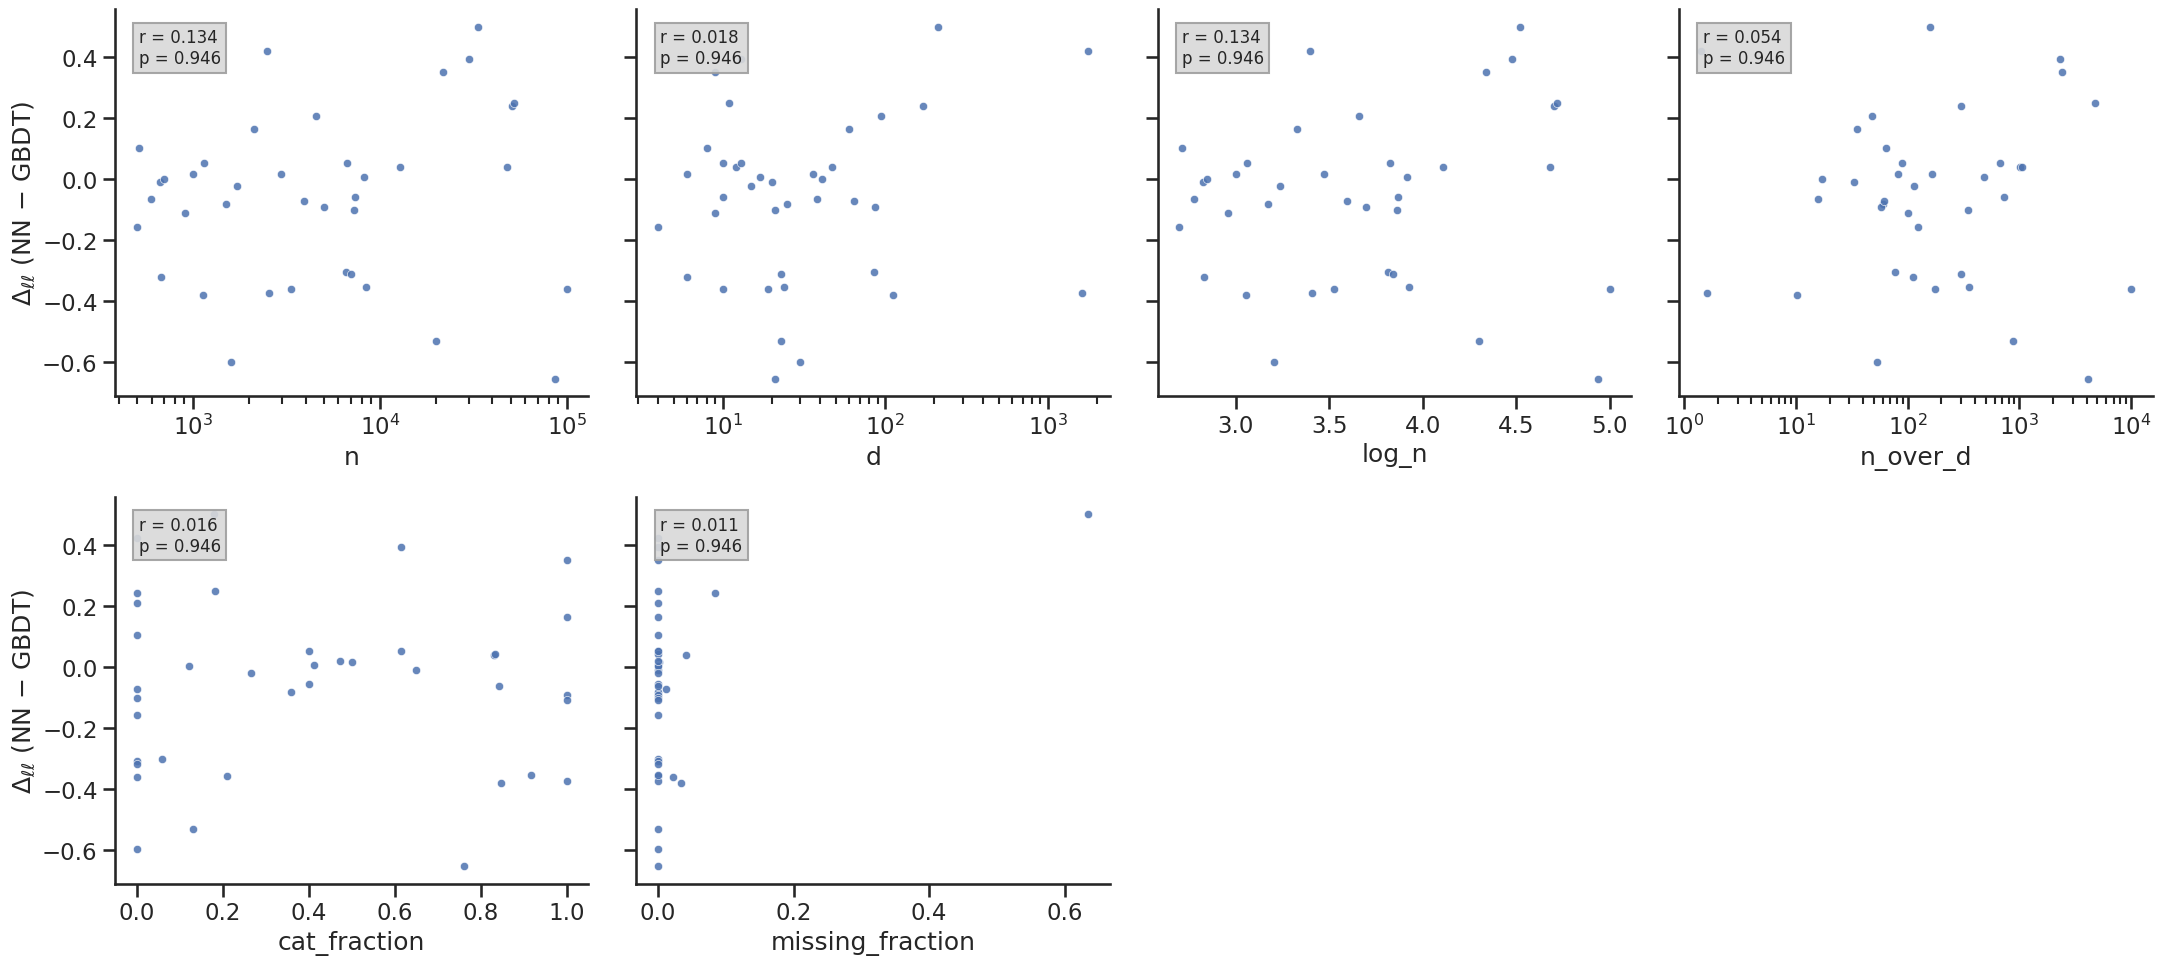

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", context="talk")

analysis = result.analysis_table.copy()
predictors = corr_df["predictor"].tolist()
n_preds = len(predictors)
ncols = min(4, n_preds)
nrows = int(np.ceil(n_preds / ncols))

fig, axes = plt.subplots(
    nrows, ncols, figsize=(5.5 * ncols, 5 * nrows), sharey=True, squeeze=False
)

for idx, predictor in enumerate(predictors):
    ax = axes[idx // ncols][idx % ncols]
    plot_df = analysis[[predictor, "delta_norm"]].dropna()

    # Use log scale for features that are strictly positive and span orders of magnitude
    use_log = (plot_df[predictor] > 0).all() and (
        plot_df[predictor].max() / plot_df[predictor].min() > 10
    )

    sns.scatterplot(data=plot_df, x=predictor, y="delta_norm", s=35, alpha=0.85, ax=ax)
    if use_log:
        ax.set_xscale("log")

    ax.set_xlabel(predictor)
    if idx % ncols == 0:
        ax.set_ylabel(r"$\Delta_{\ell\ell}$ (NN − GBDT)")
    else:
        ax.set_ylabel("")

    # Annotate with correlation and adjusted p-value
    row = corr_df.loc[corr_df["predictor"] == predictor].iloc[0]
    p_display = row.get("p_value_adj", row["p_value"])
    ax.text(
        0.05,
        0.95,
        f"r = {row['statistic']:.3f}\np = {p_display:.3f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        bbox={"facecolor": "#d9d9d9", "edgecolor": "#9e9e9e", "alpha": 0.9},
    )

# Hide unused subplots
for idx in range(n_preds, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

sns.despine()
fig.tight_layout()
plt.show()